In [2]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.84.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached ml_dtypes-0.6.0-cp313-cp313-win_amd64.whl.metadata (8.8 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached opt

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [4]:
# 1. Load the dataset
data = pd.read_csv("city_day.csv")

In [5]:
# 2. Select required pollutant features
features = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]

data = data[features + ["AQI"]].dropna()


In [6]:
# 3. Convert AQI into levels
# 0 = Good, 1 = Moderate, 2 = Poor, 3 = Very Poor, 4 = Severe
def aqi_level(aqi):
    if aqi <= 50:
        return 0
    elif aqi <= 100:
        return 1
    elif aqi <= 200:
        return 2
    elif aqi <= 300:
        return 3
    else:
        return 4

data["AQI_Level"] = data["AQI"].apply(aqi_level)

In [7]:
# 4. Separate features and target
X = data[features]
y = data["AQI_Level"]

In [8]:
# 5. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# 6. Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
# 7. Build the ANN model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(5, activation="softmax")
])

In [11]:
# 8. Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [12]:
# 9. Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6489 - loss: 0.9916 - val_accuracy: 0.7479 - val_loss: 0.6870
Epoch 2/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7503 - loss: 0.6159 - val_accuracy: 0.7607 - val_loss: 0.5767
Epoch 3/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7761 - loss: 0.5503 - val_accuracy: 0.7791 - val_loss: 0.5443
Epoch 4/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7903 - loss: 0.5223 - val_accuracy: 0.7818 - val_loss: 0.5211
Epoch 5/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7951 - loss: 0.5072 - val_accuracy: 0.7849 - val_loss: 0.5091
Epoch 6/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7988 - loss: 0.4985 - val_accuracy: 0.7896 - val_loss: 0.5029
Epoch 7/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8030 - loss: 0.4939 - val_accuracy: 0.7861 - val_loss: 0.4989
Epoch 8/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8029 - loss: 0.4894 - val_accuracy: 0.

In [13]:
# 10. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", round(loss, 4))
print("Test Accuracy:", round(accuracy, 4))

Test Loss: 0.4598
Test Accuracy: 0.8126


In [14]:
# 11. Make predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Prediction Accuracy:",
      round(accuracy_score(y_test, y_pred), 4))

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   
Prediction Accuracy: 0.8126


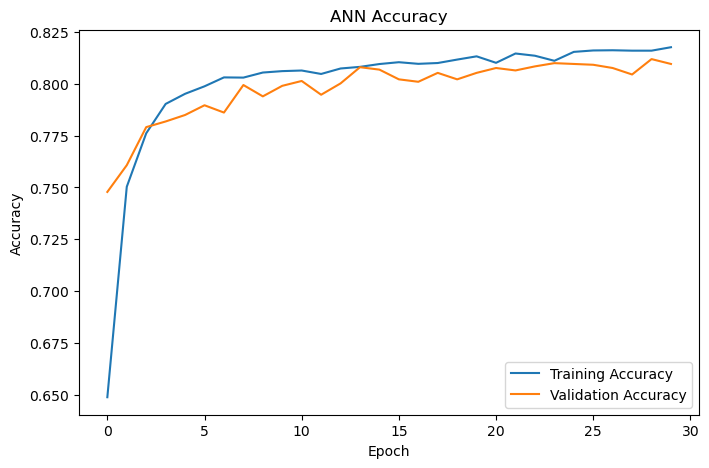

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy")
plt.legend()
plt.show()

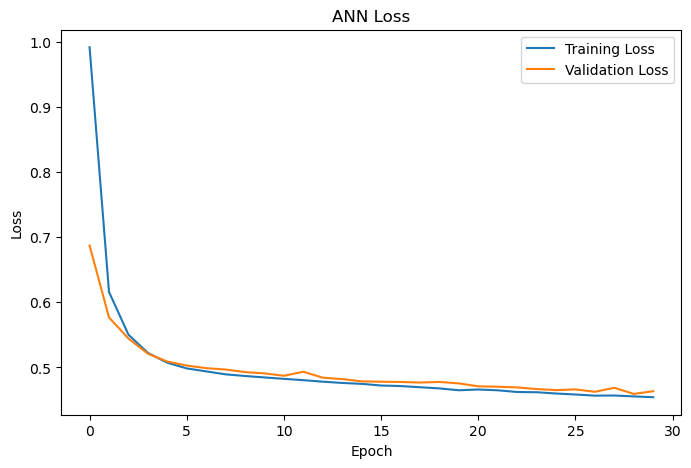

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Loss")
plt.legend()
plt.show()